### Graficas o insights para Genero, Ingresos y composición familiar

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sbn
import numpy as np

In [2]:
# cargamos el dataset
ROOT  = Path('..').resolve()
sex_ing_pers = pd.read_csv(ROOT/'sex_ing_nopersonas.csv', sep=';')
display(sex_ing_pers.head())

,SEXO,INGRESO_FAMILIA,NUMERO_PERSONAS_FAMILIA,ESTRATO,TIPO,1998-1,1998-2,1999-1,1999-2,2000-1,...,2020-1,2020-2,2021-1,2021-2,2022-1,2022-2,2023-1,2023-2,2024-1,2024-2
0,Mujer,Sin informaci¿n,Sin informaci¿n,Sin informaci¿n,DESERTORES,0.0,0.0,21629.0,10106.0,12700.0,...,43298.0,71352.0,71463.0,78056.0,69262.0,118250.0,88202.0,150003.0,109381.0,152061.0
1,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 1,DESERTORES,0.0,0.0,1.0,3.0,6.0,...,1472.0,2342.0,1283.0,1670.0,1255.0,1934.0,1212.0,2143.0,1076.0,1679.0
2,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 2,DESERTORES,0.0,0.0,10.0,10.0,21.0,...,4332.0,7094.0,3991.0,5055.0,3578.0,5909.0,3723.0,6237.0,3226.0,5021.0
3,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 3,DESERTORES,0.0,0.0,4.0,4.0,1.0,...,1867.0,2640.0,1615.0,1960.0,1451.0,2236.0,1407.0,2294.0,1222.0,1932.0
4,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 4,DESERTORES,NaN,0.0,NaN,0.0,1.0,...,91.0,121.0,81.0,88.0,78.0,104.0,70.0,95.0,44.0,72.0


In [3]:
# Exploramos las columnas y datos que tenemos así como su tipo
display(sex_ing_pers.info())
display(sex_ing_pers['SEXO'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3136 entries, 0 to 3135
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEXO                     3136 non-null   object 
 1   INGRESO_FAMILIA          3136 non-null   object 
 2   NUMERO_PERSONAS_FAMILIA  3136 non-null   object 
 3   ESTRATO                  3136 non-null   object 
 4   TIPO                     3136 non-null   object 
 5   1998-1                   664 non-null    float64
 6   1998-2                   652 non-null    float64
 7   1999-1                   692 non-null    float64
 8   1999-2                   696 non-null    float64
 9   2000-1                   768 non-null    float64
 10  2000-2                   906 non-null    float64
 11  2001-1                   890 non-null    float64
 12  2001-2                   870 non-null    float64
 13  2002-1                   892 non-null    float64
 14  2002-2                  

None

SEXO
Hombre             1536
Mujer              1534
Sin informaci¿n      66
Name: count, dtype: int64

A priori podemos suprimir los valores de sin información en el campo del sexo

In [4]:
valores_sin_informacion_sexo = sex_ing_pers[sex_ing_pers['SEXO'] != 'Sin informaci¿n'].reset_index(drop=True)
display(valores_sin_informacion_sexo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3070 entries, 0 to 3069
Data columns (total 59 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SEXO                     3070 non-null   object 
 1   INGRESO_FAMILIA          3070 non-null   object 
 2   NUMERO_PERSONAS_FAMILIA  3070 non-null   object 
 3   ESTRATO                  3070 non-null   object 
 4   TIPO                     3070 non-null   object 
 5   1998-1                   662 non-null    float64
 6   1998-2                   650 non-null    float64
 7   1999-1                   690 non-null    float64
 8   1999-2                   694 non-null    float64
 9   2000-1                   766 non-null    float64
 10  2000-2                   904 non-null    float64
 11  2001-1                   888 non-null    float64
 12  2001-2                   868 non-null    float64
 13  2002-1                   890 non-null    float64
 14  2002-2                  

None

Hacemos la conversión de formato ancho a formato largo

In [5]:
columnas_stay = ['SEXO','INGRESO_FAMILIA','NUMERO_PERSONAS_FAMILIA','ESTRATO','TIPO']
columnas_melt = [col for col in valores_sin_informacion_sexo.columns if valores_sin_informacion_sexo[col].dtype in ['float64','float32']]
print(columnas_melt)
long_sex_ing_pers = valores_sin_informacion_sexo.melt(
    id_vars=columnas_stay,
    value_vars=columnas_melt,       # lista de '2015-1', '2015-2', ...
    var_name='periodo',
    value_name='valor'
)
display(long_sex_ing_pers.head())

['1998-1', '1998-2', '1999-1', '1999-2', '2000-1', '2000-2', '2001-1', '2001-2', '2002-1', '2002-2', '2003-1', '2003-2', '2004-1', '2004-2', '2005-1', '2005-2', '2006-1', '2006-2', '2007-1', '2007-2', '2008-1', '2008-2', '2009-1', '2009-2', '2010-1', '2010-2', '2011-1', '2011-2', '2012-1', '2012-2', '2013-1', '2013-2', '2014-1', '2014-2', '2015-1', '2015-2', '2016-1', '2016-2', '2017-1', '2017-2', '2018-1', '2018-2', '2019-1', '2019-2', '2020-1', '2020-2', '2021-1', '2021-2', '2022-1', '2022-2', '2023-1', '2023-2', '2024-1', '2024-2']


,SEXO,INGRESO_FAMILIA,NUMERO_PERSONAS_FAMILIA,ESTRATO,TIPO,periodo,valor
0,Mujer,Sin informaci¿n,Sin informaci¿n,Sin informaci¿n,DESERTORES,1998-1,0.0
1,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 1,DESERTORES,1998-1,0.0
2,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 2,DESERTORES,1998-1,0.0
3,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 3,DESERTORES,1998-1,0.0
4,Mujer,Sin informaci¿n,Sin informaci¿n,Estrato 4,DESERTORES,1998-1,NaN


Verificamos NaNs o nulls para limpiar

In [6]:
print(long_sex_ing_pers.isnull().sum())

SEXO                           0
INGRESO_FAMILIA                0
NUMERO_PERSONAS_FAMILIA        0
ESTRATO                        0
TIPO                           0
periodo                        0
valor                      57630
dtype: int64


In [7]:
pivot = long_sex_ing_pers.pivot_table(
    index=["SEXO","INGRESO_FAMILIA","NUMERO_PERSONAS_FAMILIA","ESTRATO","periodo"],
    columns="TIPO",
    values="valor",
    aggfunc=lambda x: x.sum(min_count=1)
).reset_index()
display(pivot.head())


TIPO,SEXO,INGRESO_FAMILIA,NUMERO_PERSONAS_FAMILIA,ESTRATO,periodo,DESERTORES,MATRICULADOS
0,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,1998-1,0.0,1.0
1,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,2002-1,0.0,1.0
2,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,2002-2,1.0,1.0
3,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,2003-1,0.0,2.0
4,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,2003-2,0.0,2.0


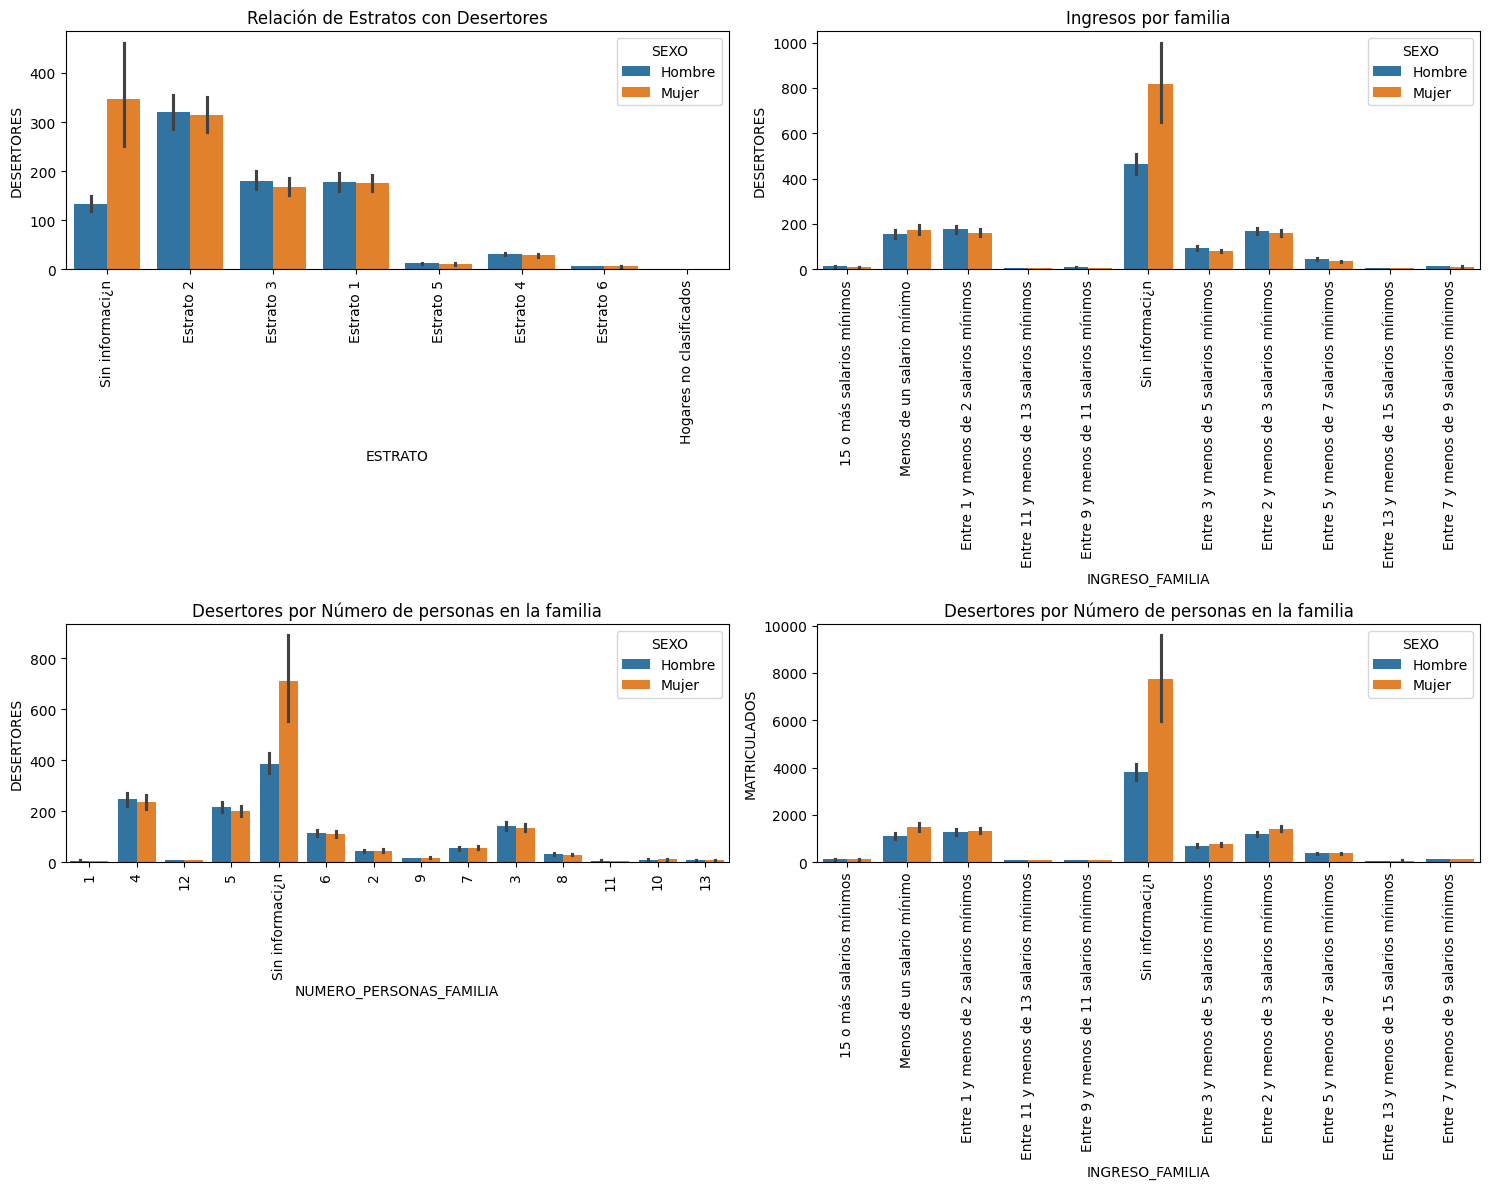

In [18]:
pivot = pivot.sort_values('periodo')
fig,axs = plt.subplots(2,2,figsize=(15,12))
sbn.barplot(
    data=pivot,
    x='ESTRATO',
    y='DESERTORES',hue='SEXO',ax=axs[0,0])
axs[0,0].tick_params(axis='x',rotation=90)
axs[0,0].set_title('Relación de Estratos con Desertores')
sbn.barplot(
    data=pivot,
    x='INGRESO_FAMILIA',
    y='DESERTORES',hue='SEXO',ax=axs[0,1])
axs[0,1].tick_params(axis='x',rotation=90)
axs[0,1].set_title('Ingresos por familia')
sbn.barplot(
    data=pivot,
    x='NUMERO_PERSONAS_FAMILIA',
    y='DESERTORES',hue='SEXO',ax=axs[1,0])
axs[1,0].tick_params(axis='x',rotation=90)
axs[1,0].set_title('Desertores por Número de personas en la familia')
sbn.barplot(
    data=pivot,
    x='INGRESO_FAMILIA',
    y='MATRICULADOS',hue='SEXO',ax=axs[1,1])
axs[1,1].tick_params(axis='x',rotation=90)
axs[1,1].set_title('Desertores por Número de personas en la familia')
plt.tight_layout()
plt.show()

In [19]:
pivot['tasa'] = round(((pivot['DESERTORES'] / pivot['MATRICULADOS']) * 100),2)
pivot['tasa'] = np.clip(pivot['tasa'],0,100)
display(pivot.head())

TIPO,SEXO,INGRESO_FAMILIA,NUMERO_PERSONAS_FAMILIA,ESTRATO,periodo,DESERTORES,MATRICULADOS,tasa
0,Hombre,15 o más salarios mínimos,1,Sin informaci¿n,1998-1,0.0,1.0,0.0
49577,Mujer,Menos de un salario mínimo,4,Sin informaci¿n,1998-1,0.0,300.0,0.0
28409,Mujer,Entre 1 y menos de 2 salarios mínimos,12,Estrato 2,1998-1,0.0,1.0,0.0
49631,Mujer,Menos de un salario mínimo,5,Sin informaci¿n,1998-1,0.0,345.0,0.0
27982,Mujer,Entre 1 y menos de 2 salarios mínimos,1,Sin informaci¿n,1998-1,0.0,27.0,0.0


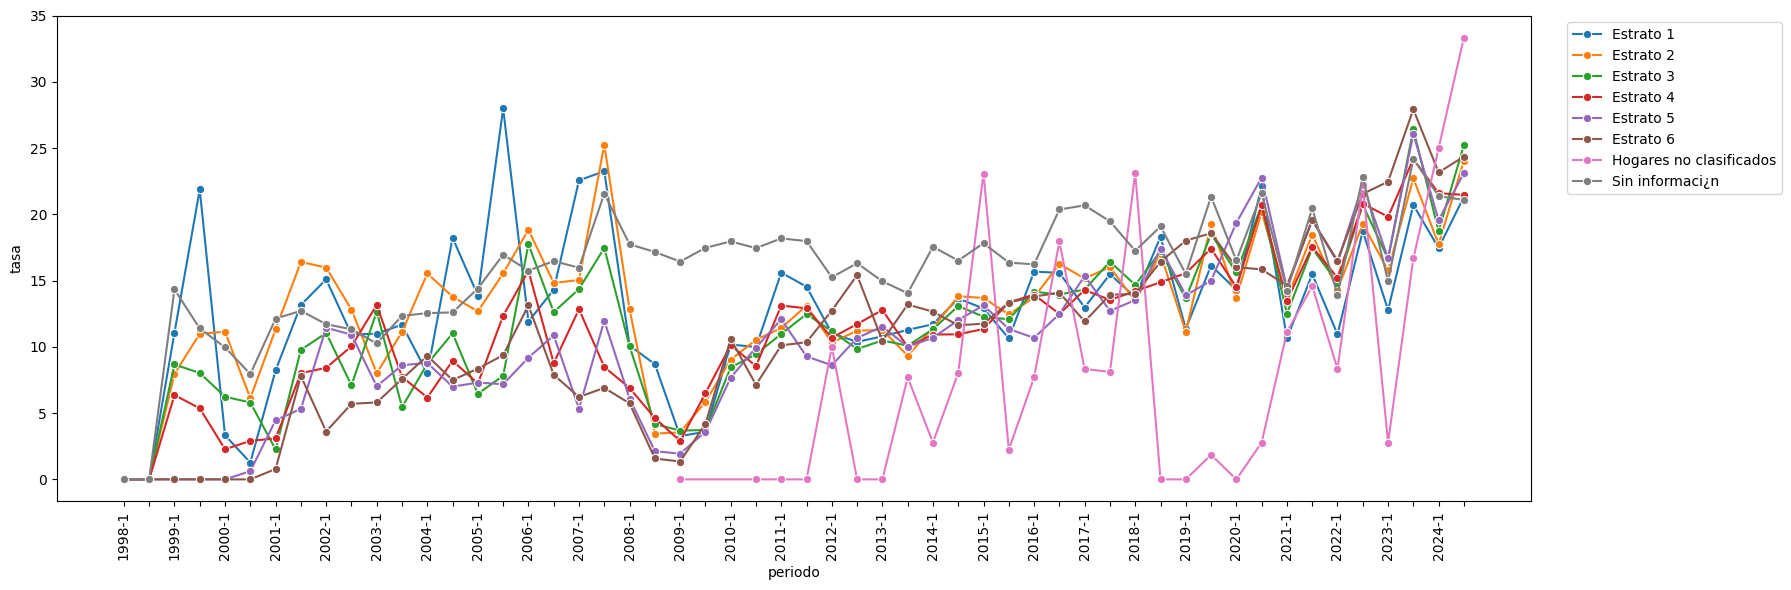

In [26]:
f= pivot.groupby(['ESTRATO','periodo'])['tasa'].mean().reset_index()
# display(f.info())
plt.figure(figsize=(18,6))
ax = sbn.lineplot(data=f, x='periodo', y='tasa', hue='ESTRATO', marker='o')

# Mostrar solo 1 de cada N etiquetas en X
for i, label in enumerate(ax.get_xticklabels()):
    if i % 2 != 0:
        label.set_visible(False)

plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
